# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [5]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [6]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [24]:
!mkdir -p data
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
!wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv
# Note that `cd data`, ..., `cd ..` doesn't work

--2026-05-29 09:56:52--  https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
Resolving b2share.eudat.eu (b2share.eudat.eu)... 86.50.166.117, 2001:708:10:6802::12
Connecting to b2share.eudat.eu (b2share.eudat.eu)|86.50.166.117|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/2p6ra-xfj86/files/X_test_sat6.csv [following]
--2026-05-29 09:56:53--  https://b2share.eudat.eu/records/2p6ra-xfj86/files/X_test_sat6.csv
Reusing existing connection to b2share.eudat.eu:443.
HTTP request sent, awaiting response... 200 OK
Length: 905628829 (864M) [text/plain]
Saving to: ‘data/X_test_sat6.csv’

X_test_sat6.csv     100%[===================>] 863.67M  10.4MB/s    in 82s     

2026-05-29 09:58:16 (10.5 MB/s) - ‘data/X_test_sat6.csv’ saved [905628829/905628829]

--2026-05-29 09:58:16--  https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
Resolving b2share.eudat.eu (b2share.eudat.eu)..

In [25]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


In [26]:
# save for each wavelength channel:
sample = landcover_df.iloc[1000].values #print(sample.shape)
img = sample.reshape(28, 28,4)

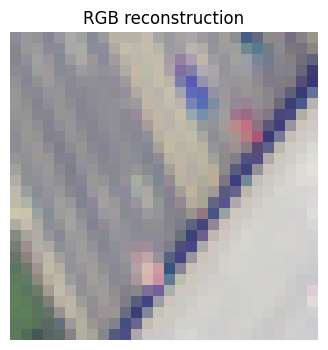

In [27]:
R   = img[:,:,0]
G   = img[:,:,1]
B   = img[:,:,2]
NIR = img[:,:,3]

rgb = np.stack([R, G, B], axis=-1) # in visual colors to check the matrix flattening

plt.figure(figsize=(4,4))
plt.imshow(rgb.astype(np.uint8))
#plt.imshow(data[0, ..., :3].astype(np.uint8))
plt.title("RGB reconstruction")
plt.axis("off")
plt.show()

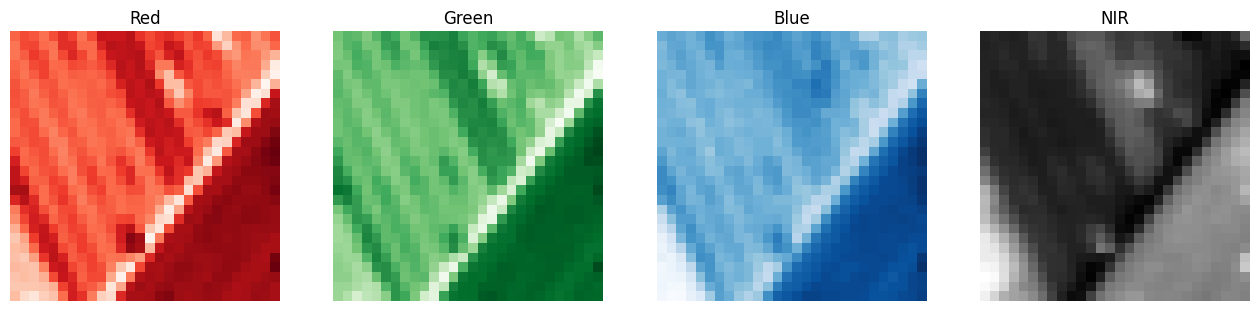

In [11]:
# Visualize to see if the picture makes sense:

fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(R, cmap='Reds')
axes[0].set_title("Red")

axes[1].imshow(G, cmap='Greens')
axes[1].set_title("Green")

axes[2].imshow(B, cmap='Blues')
axes[2].set_title("Blue")

axes[3].imshow(NIR, cmap='gray')
axes[3].set_title("NIR")

for ax in axes:
    ax.axis("off")

plt.show()

&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data? _Answer:_ G   = img[:,:,1], etc, see above

In [28]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: ['building' 'barren_land' 'trees' 'grassland' 'road' 'water']


The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

_Answer:_ ML algorithms operate on numerical data, so class labels must be encoded numerically rather than as text. Numerical encoding is also more memory-efficient and computationally faster than string labels.

One-hot encoding prevents the model from interpreting class labels as ordinal values. For example, labels 0,1,2,3,4,5 may incorrectly imply that class 5 is “larger” or “closer” to class 4 than to class 1, although the classes are actually categorical and unordered.

In [29]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values


       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

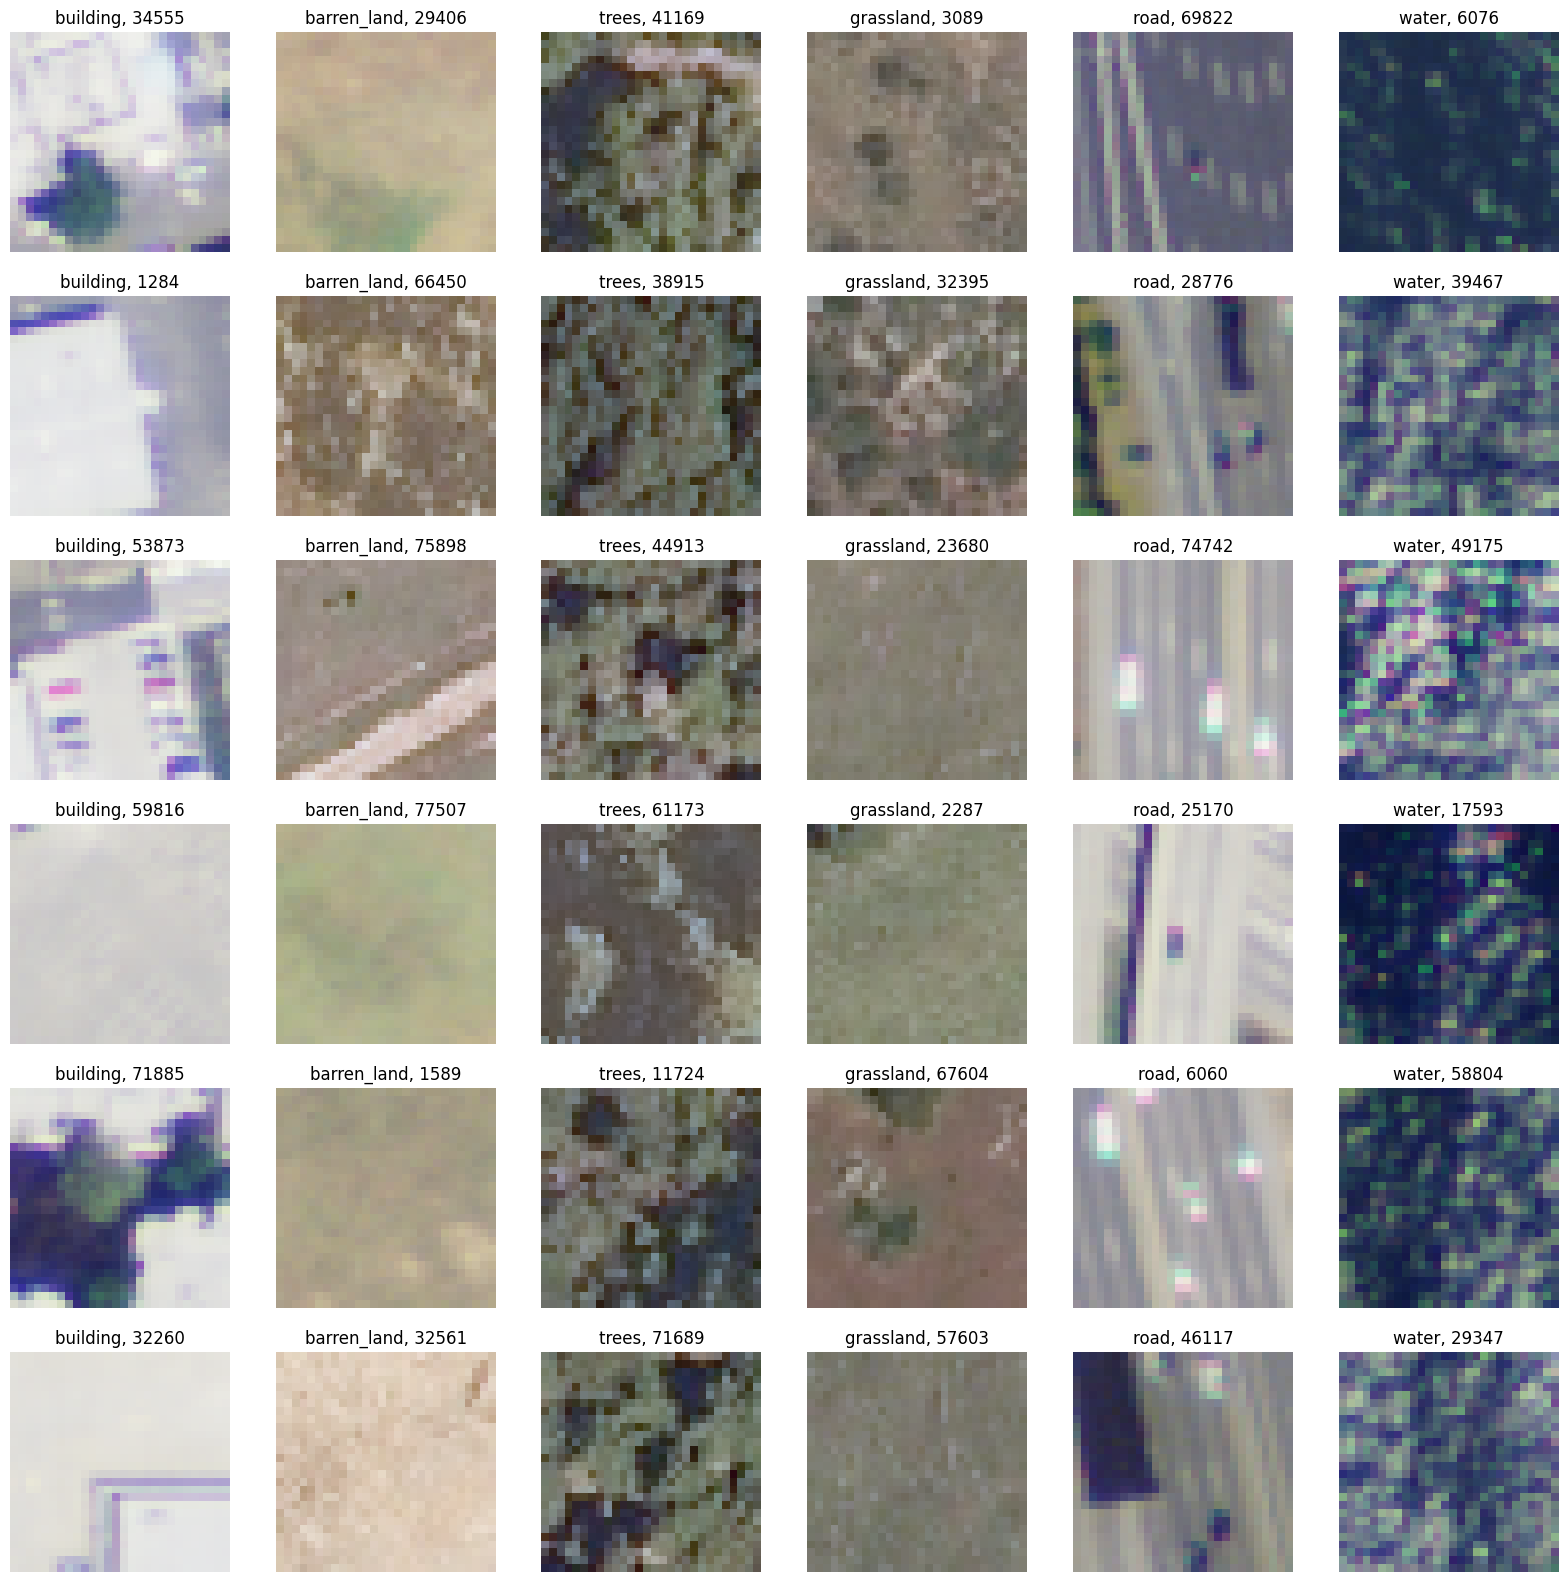

In [30]:
num_classes = len(column_names)
num_samples = 6  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

Collect equal number of samples **from each class** for training and testing, respectively

In [31]:
# num_train = 1000
# num_test = 100
# train_idx = []
# test_idx = []
# for column in column_names:
#     # find all indices of a given class
#     class_idx = labels_df[column] == 1
#     # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
#     train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
#     test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
# print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


&#x1F479;  _Question:_ Why use `extend`here and `append` above? _Answer:_ need a vector, not a nested array

&#x1F479;  _Question:_ What is wrong with the above code? _Answer:_ there is an overlap possible for a data between the train and test samples -> consider overfitting.

In [32]:
# correct the code above:

num_train = 1000
num_test = 100
num_all = num_train + num_test
train_idx = []
test_idx = []
for column in column_names:
    class_idx = labels_df[column] == 1   # find all indices of a given class
    indices = np.where(class_idx.values)[0] # booleen to numbers
    selected_idx = np.random.choice(indices, size=num_all, replace=False)

    train_idx.extend(selected_idx[:num_train].tolist())
    test_idx.extend(selected_idx[num_train:].tolist())

print(f'number of train indices: {len(train_idx)}')
print(f'number of test indices: {len(test_idx)}')

overlap = set(train_idx).intersection(set(test_idx))
print(f'overlap between train and test: {len(overlap)}')

number of train indices: 6000
number of test indices: 600
overlap between train and test: 0


In [33]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets? _Answer:_ to avoid data ordering by class

In [34]:
train_X

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
65265,92,87,77,136,65,63,54,105,112,115,...,118,165,61,52,42,77,58,48,38,66
54881,83,108,106,165,86,108,107,166,89,114,...,176,76,189,187,179,85,191,187,182,89
80288,112,105,91,183,122,114,102,189,108,99,...,64,189,77,83,65,187,77,83,64,188
4581,24,37,67,5,17,23,59,4,25,44,...,96,10,80,84,99,12,85,120,99,13
67673,87,94,81,176,83,86,78,172,79,81,...,37,149,90,94,80,183,91,88,74,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35314,88,112,89,201,85,107,91,196,93,114,...,98,192,97,104,99,191,70,81,92,180
17070,129,126,110,182,129,126,112,179,126,121,...,109,188,118,119,98,182,116,120,104,186
2626,192,178,141,175,173,162,140,172,172,160,...,122,156,132,134,121,165,144,145,119,176
50099,102,104,93,150,110,117,112,163,109,112,...,93,172,76,80,54,146,95,105,90,165


## Define and intialize random classifier from scikit-learn

In [35]:
rf = RandomForestClassifier(n_estimators=10)

## Train the random forest

In [36]:
rf.fit( train_X, train_y)

RandomForestClassifier(n_estimators=10)

## Check the prediction on the test set

In [37]:
rf.score(test_X, test_y)

0.8866666666666667

In [38]:
print(test_X.shape)

(600, 3136)


&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)

In [46]:
print(test_y.shape)
print(pred_y.shape)

(600, 6)
(600, 6)


In [47]:
pred_y = rf.predict(test_X) # predict a test set

# flatten the one-hot encoding:
class_test_y = np.argmax(test_y, axis=1)
class_pred_y = np.argmax(pred_y, axis=1)

correct_idx = np.where(class_pred_y == class_test_y)[0]
wrong_idx   = np.where(class_pred_y != class_test_y)[0]
print(f'number of correct predictions: {len(correct_idx)}')
print(f'number of wrong predictions: {len(wrong_idx)}')

number of correct predictions: 541
number of wrong predictions: 59


In [61]:
n_success = 25 # choose n_examples from test set to inspect
n_failure = 30
success_idx = np.random.choice(correct_idx,size=min(n_success, len(correct_idx)),replace=False)
failure_idx = np.random.choice(wrong_idx,size=min(n_failure, len(wrong_idx)),replace=False)
print(success_idx)

[ 85 182 189 238 252 320 509 265 184 211 337 461  88 530 152 410 498 340
  76 129 283 266  71 171  56]


In [66]:
print(labels[class_pred_y[success_idx[1]]])

road


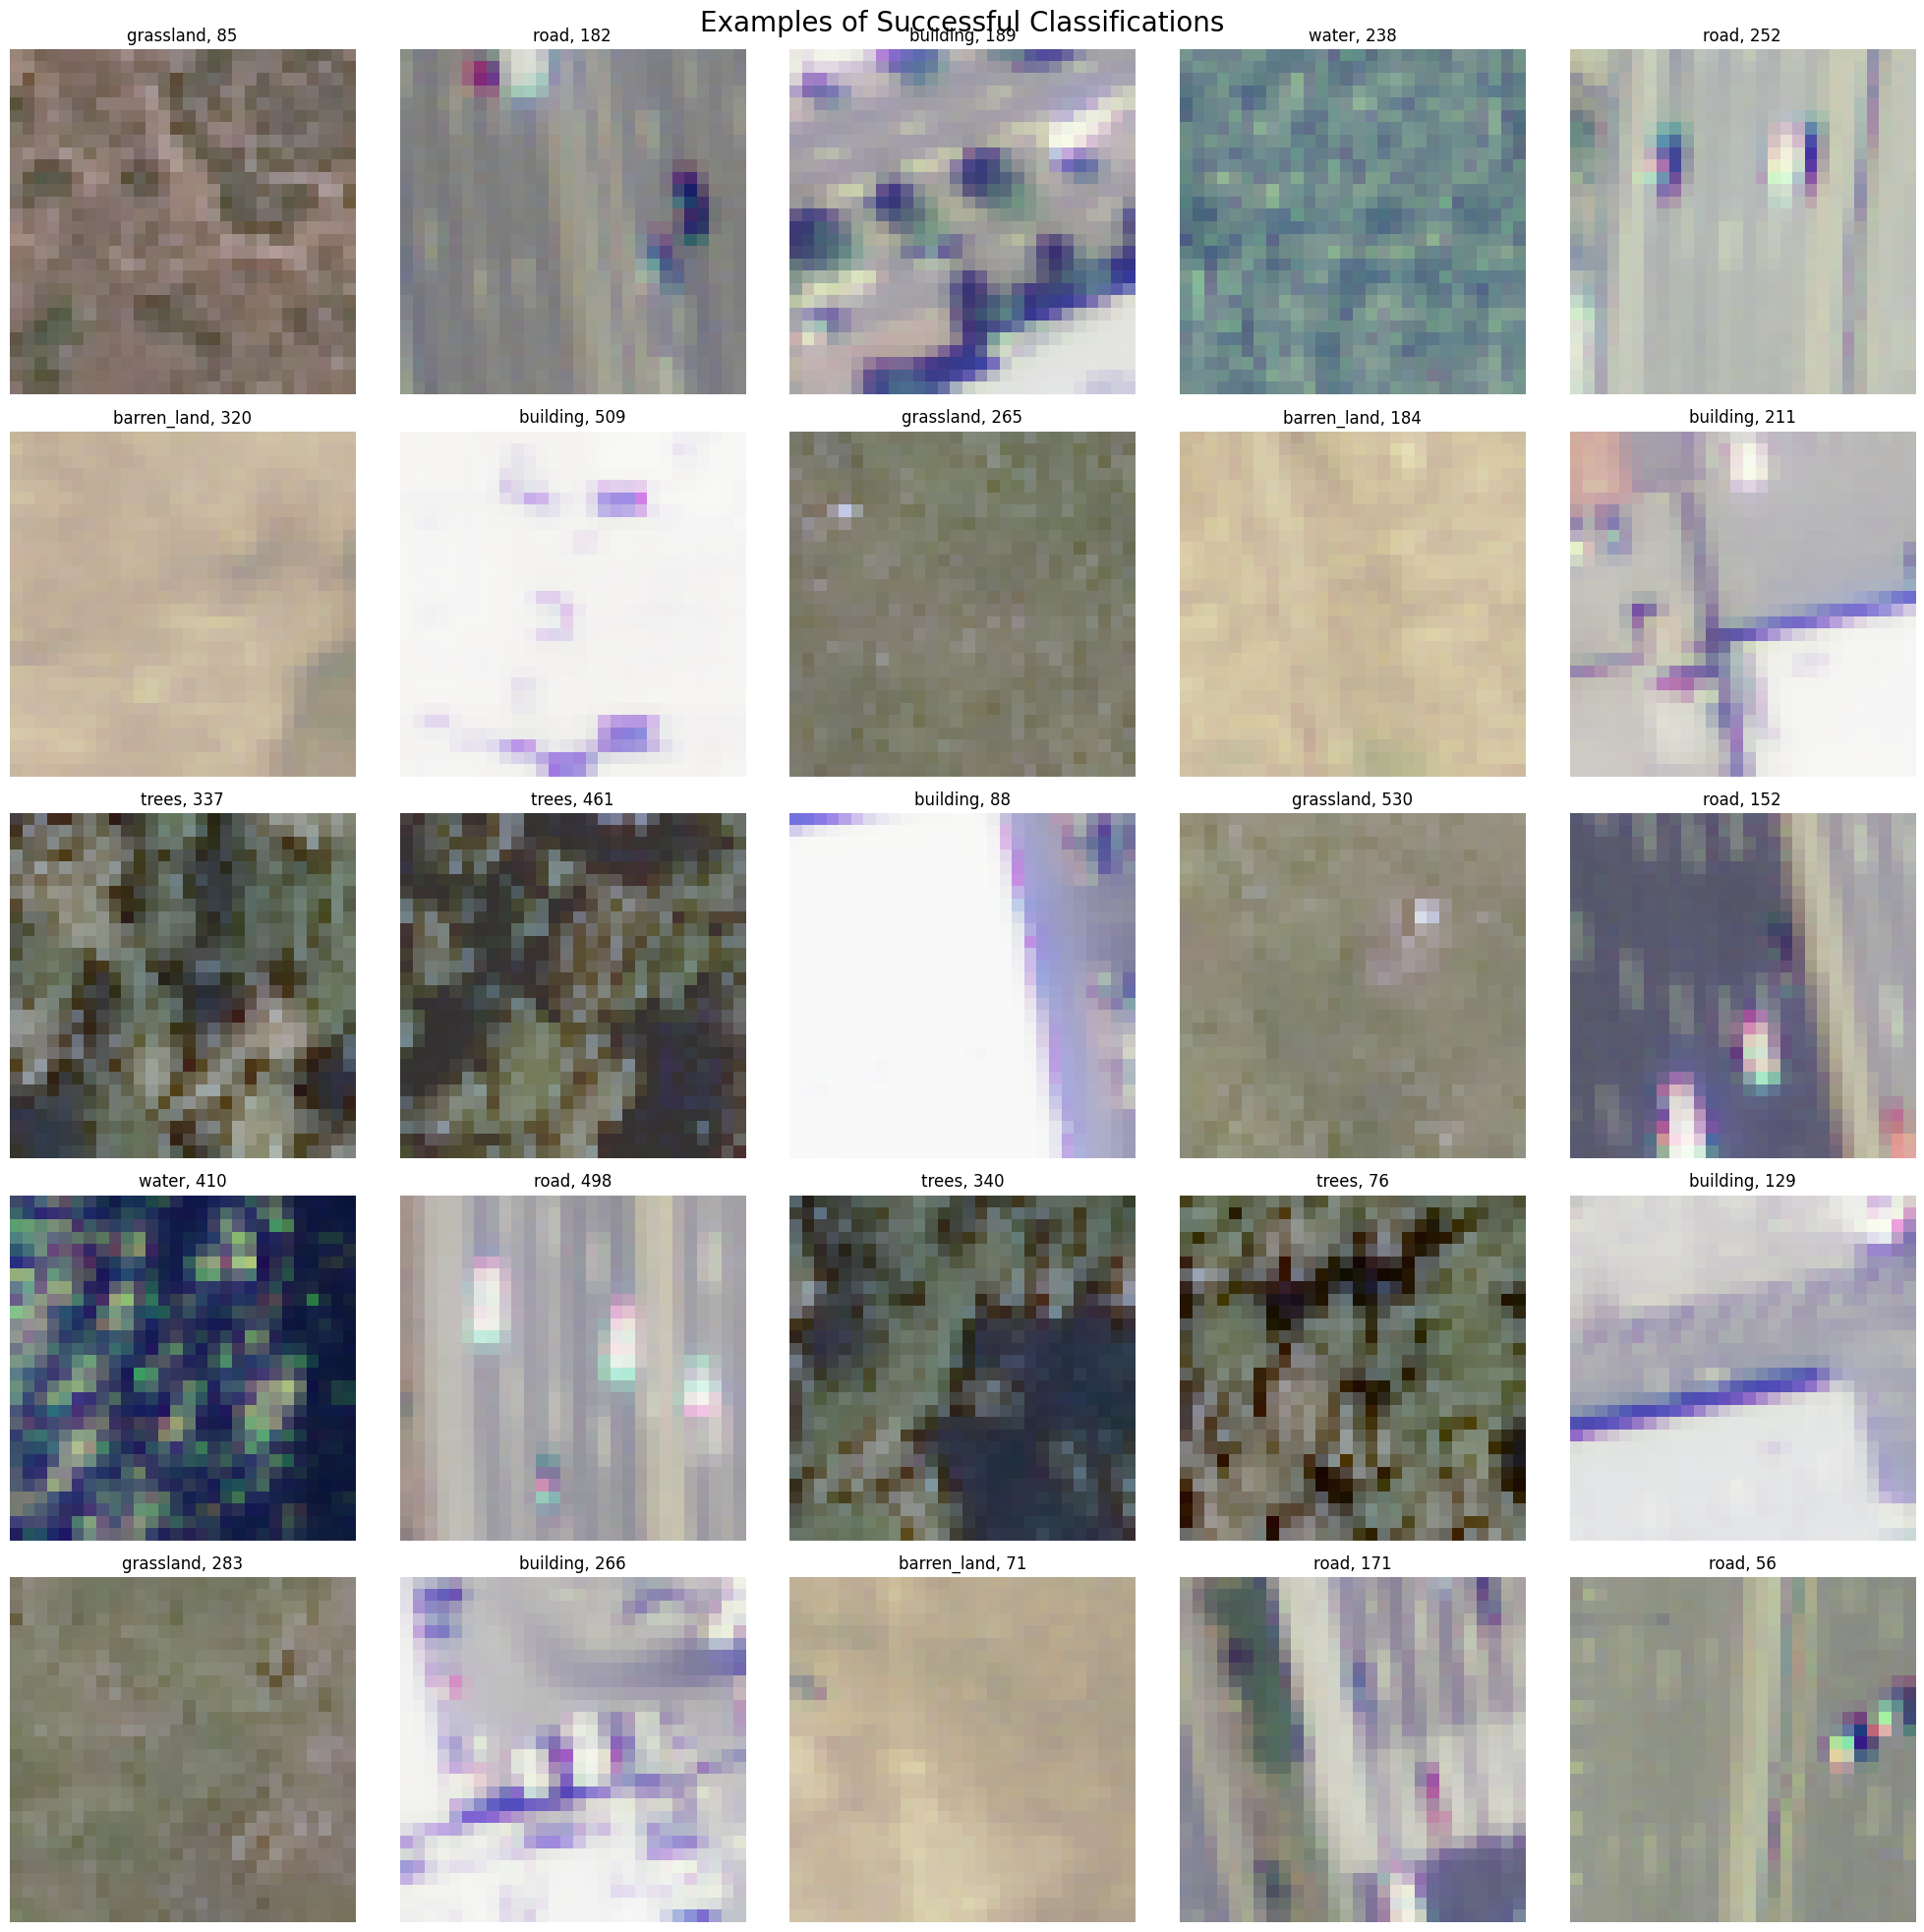

In [69]:

fig, ax = plt.subplots(5, 5, figsize=(20, 20)) # for n_success = 25


for k, idx in enumerate(success_idx):
    row = k // 5
    col = k % 5

    data = np.reshape(test_X.iloc[idx, :].values,(-1, 28, 28, 4))

    ax[row, col].imshow(data[0, ..., :3].astype(np.uint8))
    ax[row, col].set_title(f"{labels[class_pred_y[idx]]}, {idx}")
    ax[row, col].axis("off")

fig.suptitle("Examples of Successful Classifications",fontsize=20)#,y=0.92)
plt.tight_layout()
plt.show()
